In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/breast-cancer.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [68]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [69]:
#Data understanding
print(df.shape)
print("\n",df.dtypes)
print("\n",df.describe())


(569, 32)

 id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavit

In [70]:
# covert target into numerical
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
print(df)

           id  diagnosis  radius_mean  texture_mean  perimeter_mean  \
0      842302          1        17.99         10.38          122.80   
1      842517          1        20.57         17.77          132.90   
2    84300903          1        19.69         21.25          130.00   
3    84348301          1        11.42         20.38           77.58   
4    84358402          1        20.29         14.34          135.10   
..        ...        ...          ...           ...             ...   
564    926424          1        21.56         22.39          142.00   
565    926682          1        20.13         28.25          131.20   
566    926954          1        16.60         28.08          108.30   
567    927241          1        20.60         29.33          140.10   
568     92751          0         7.76         24.54           47.92   

     area_mean  smoothness_mean  compactness_mean  concavity_mean  \
0       1001.0          0.11840           0.27760         0.30010   
1       1

In [71]:
#imbalance checking
print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [72]:
#checking imbalance in %
print("Class Distribution:")
print(df['diagnosis'].value_counts(normalize=True) * 100)

Class Distribution:
diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


In [73]:
#Data cleaning
df=df.drop(columns=['id'])

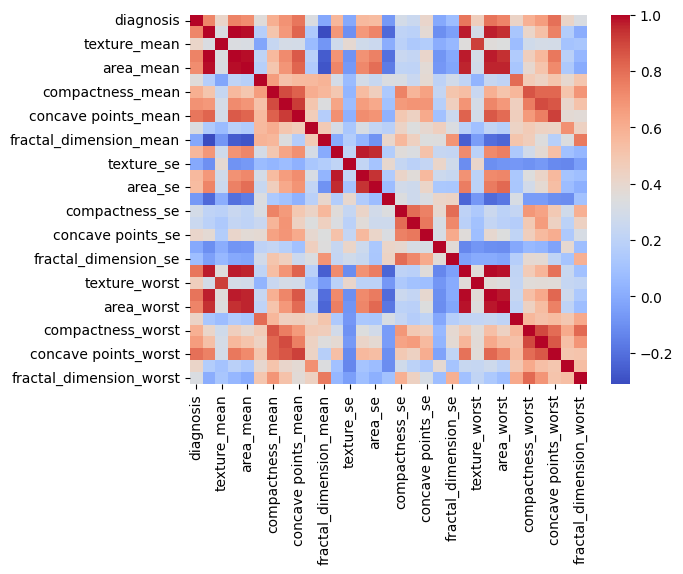

In [74]:
#EDA
#Heat map
import seaborn as sns
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

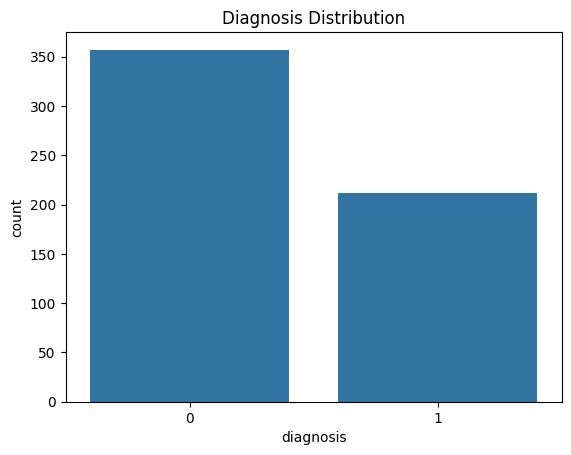

In [75]:
#count plot
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Distribution")
plt.show()

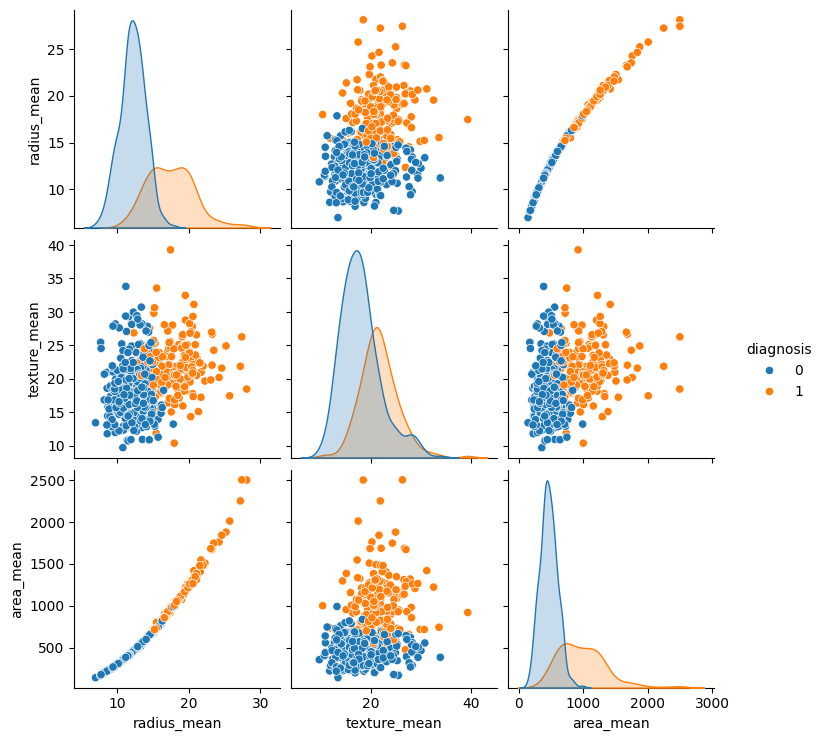

In [76]:
#pairplot
sns.pairplot(df[['diagnosis','radius_mean','texture_mean','area_mean']], hue='diagnosis')
plt.show()

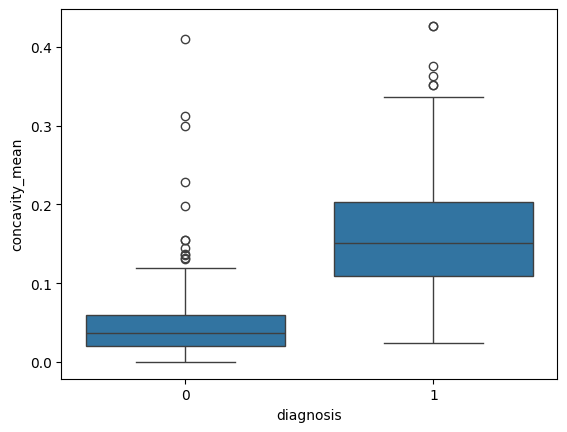

In [77]:
#boxplot
sns.boxplot(x='diagnosis', y='concavity_mean', data=df)
plt.show()

In [78]:
#split features & target
x = df.drop(columns=["diagnosis"],axis=1)
y = df["diagnosis"]

In [79]:
#Feature selection
corr_matrix = x.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
x = x.drop(columns=to_drop)

print("Dropped columns:", x)


Dropped columns:      radius_mean  texture_mean  smoothness_mean  compactness_mean  \
0          17.99         10.38          0.11840           0.27760   
1          20.57         17.77          0.08474           0.07864   
2          19.69         21.25          0.10960           0.15990   
3          11.42         20.38          0.14250           0.28390   
4          20.29         14.34          0.10030           0.13280   
..           ...           ...              ...               ...   
564        21.56         22.39          0.11100           0.11590   
565        20.13         28.25          0.09780           0.10340   
566        16.60         28.08          0.08455           0.10230   
567        20.60         29.33          0.11780           0.27700   
568         7.76         24.54          0.05263           0.04362   

     concavity_mean  symmetry_mean  fractal_dimension_mean  radius_se  \
0           0.30010         0.2419                 0.07871     1.0950   
1       

In [80]:
#train-test-split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [81]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [82]:
#smote to avoid imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

In [83]:
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_sm.value_counts())

Before SMOTE:
 diagnosis
0    286
1    169
Name: count, dtype: int64
After SMOTE:
 diagnosis
0    286
1    286
Name: count, dtype: int64


In [84]:
#modeling
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression(random_state=42)
lg.fit(x_train_sm, y_train_sm)

LogisticRegression(random_state=42)

In [85]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_sm, y_train_sm)


DecisionTreeClassifier(random_state=42)

In [86]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [87]:
from sklearn.svm import SVC
sv=SVC(probability=True,random_state=42)
sv.fit(x_train_sm, y_train_sm)



SVC(probability=True, random_state=42)

In [88]:
from xgboost import XGBClassifier
xgb= XGBClassifier(random_state=42)
xgb.fit(x_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [89]:
y_pred_lg=lg.predict(x_test)
y_pred_dt=dt.predict(x_test)
y_pred_rf=rf.predict(x_test)
y_pred_sv=sv.predict(x_test)
y_pred_xgb=xgb.predict(x_test)


In [90]:
y_prob_lg = lg.predict_proba(x_test)[:,1]
y_prob_dt = dt.predict_proba(x_test)[:,1]
y_prob_rf = rf.predict_proba(x_test)[:,1]
y_prob_sv = sv.predict_proba(x_test)[:,1]
y_prob_xgb = xgb.predict_proba(x_test)[:,1]



In [91]:
#Evaluation and confusion matrix
# Evaluation of Logistic Regression (Classification)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import confusion_matrix

lg_accuracy = accuracy_score(y_test, y_pred_lg)
lg_precision = precision_score(y_test, y_pred_lg)
lg_recall = recall_score(y_test, y_pred_lg)
lg_f1 = f1_score(y_test, y_pred_lg)
lg_roc=roc_auc_score(y_test,y_prob_lg)
lg_cm=confusion_matrix(y_test,y_pred_lg)

print("Logistic Regression Metrics:")
print("Accuracy :", lg_accuracy)
print("Precision:", lg_precision)
print("Recall   :", lg_recall)
print("F1 Score :", lg_f1)
print("ROC Score:",lg_roc)
print("Confusion_matrix:",lg_cm)

Logistic Regression Metrics:
Accuracy : 0.9649122807017544
Precision: 0.9333333333333333
Recall   : 0.9767441860465116
F1 Score : 0.9545454545454546
ROC Score: 0.9963969865705863
Confusion_matrix: [[68  3]
 [ 1 42]]


In [93]:
#Evaluation of Decision Tree and confusion matrix
dt_accuracy=accuracy_score(y_test,y_pred_dt)
dt_precision=precision_score(y_test,y_pred_dt)
dt_recall=recall_score(y_test,y_pred_dt)
dt_f1=f1_score(y_test,y_pred_dt)
dt_roc=roc_auc_score(y_test,y_prob_dt)
dt_cm=confusion_matrix(y_test,y_pred_dt)

print("Decision Tree Metrics:")
print("Accuracy:",dt_accuracy)
print("Precision:",dt_precision)
print("Recall:",dt_recall)
print("F1 Score:",dt_f1)
print("ROC Score:",dt_roc)
print("Confusion_matrix:",dt_cm)

Decision Tree Metrics:
Accuracy: 0.9210526315789473
Precision: 0.8695652173913043
Recall: 0.9302325581395349
F1 Score: 0.898876404494382
ROC Score: 0.9228627579430069
Confusion_matrix: [[65  6]
 [ 3 40]]


In [94]:
#Evaluation of Random forest and confusion matrix
rf_accuracy=accuracy_score(y_test,y_pred_rf)
rf_precision=precision_score(y_test,y_pred_rf)
rf_recall=recall_score(y_test,y_pred_rf)
rf_f1=f1_score(y_test,y_pred_rf)
rf_roc=roc_auc_score(y_test,y_prob_rf)
rf_cm=confusion_matrix(y_test,y_pred_rf)

print("Random Forest Metrics:")
print("Accuracy:",rf_accuracy)
print("Precision:",rf_precision)
print("Recall:",rf_recall)
print("F1 Score:",rf_f1)
print("ROC Score:",rf_roc)
print("Confusion_matrix:",rf_cm)

Random Forest Metrics:
Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412
ROC Score: 0.9918113331149689
Confusion_matrix: [[70  1]
 [ 2 41]]


In [95]:
#evaluation of SVM and confusion matrix
sv_accuracy=accuracy_score(y_test,y_pred_sv)
sv_precision=precision_score(y_test,y_pred_sv)
sv_recall=recall_score(y_test,y_pred_sv)
sv_f1=f1_score(y_test,y_pred_sv)
sv_roc=roc_auc_score(y_test,y_prob_sv)
sv_cm=confusion_matrix(y_test,y_pred_sv)
print("SVM Metrics:")
print("Accuracy:",sv_accuracy)
print("Precision:",sv_precision)
print("Recall:",sv_recall)
print("F1 Score:",sv_f1)
print("ROC Score:",sv_roc)
print("Confusion_matrix:",sv_cm)

SVM Metrics:
Accuracy: 0.9385964912280702
Precision: 0.9285714285714286
Recall: 0.9069767441860465
F1 Score: 0.9176470588235294
ROC Score: 0.9908286930887651
Confusion_matrix: [[68  3]
 [ 4 39]]


In [96]:
#Evaluation of XBooster and confusion matrix
xgb_accuracy=accuracy_score(y_test,y_pred_xgb)
xgb_precision=precision_score(y_test,y_pred_xgb)
xgb_recall=recall_score(y_test,y_pred_xgb)
xgb_f1=f1_score(y_test,y_pred_xgb)
xgb_roc=roc_auc_score(y_test,y_prob_xgb)
xgb_cm=confusion_matrix(y_test,y_pred_xgb)

print("XBooster metrics:")
print("Accuracy:",xgb_accuracy)
print("Precision:",xgb_precision)
print("Recall:",xgb_recall)
print("F1 Score:",xgb_f1)
print("ROC Score:",xgb_roc)
print("Confusion_matrix:",xgb_cm)

XBooster metrics:
Accuracy: 0.9824561403508771
Precision: 0.9767441860465116
Recall: 0.9767441860465116
F1 Score: 0.9767441860465116
ROC Score: 0.9924664264657713
Confusion_matrix: [[70  1]
 [ 1 42]]


                 Model  Accuracy  Precision    Recall  F1_score  Roc_Score
0  Logistic Regression  0.964912   0.933333  0.976744  0.954545   0.996397
1        Decision Tree  0.921053   0.869565  0.930233  0.898876   0.922863
2        Random Forest  0.973684   0.976190  0.953488  0.964706   0.991811
3                  SVM  0.938596   0.928571  0.906977  0.917647   0.990829
4              XGBOOST  0.982456   0.976744  0.976744  0.976744   0.992466

Best Model Based on F1 Score: XGBOOST




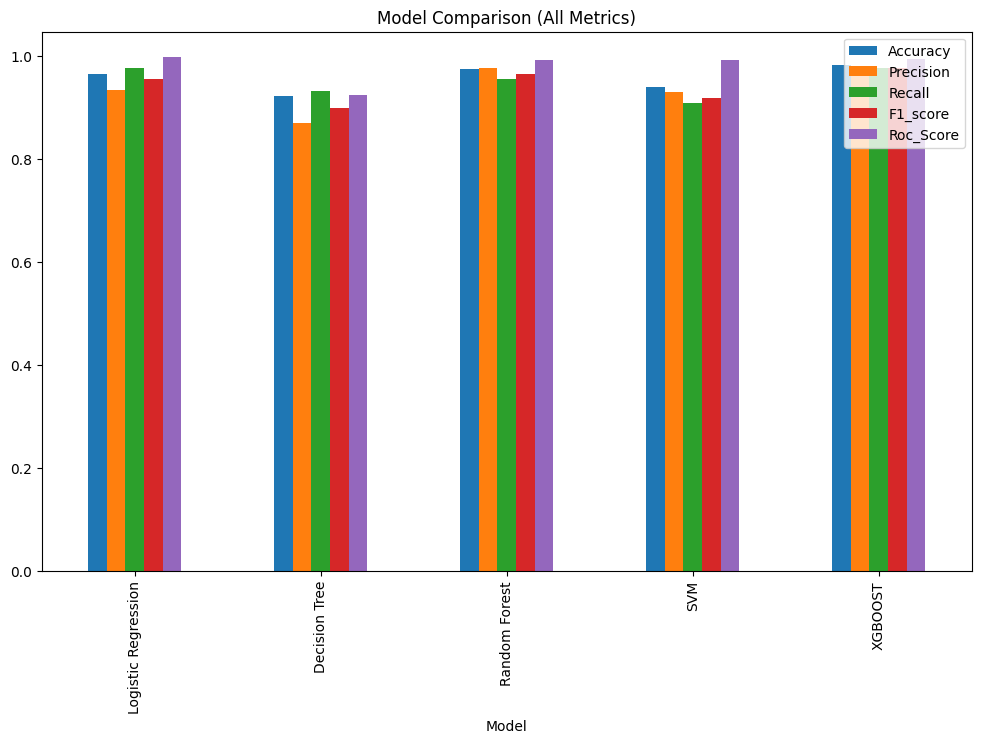

In [97]:
#Model comaparison before tuning
import pandas as pd
import matplotlib.pyplot as plt
results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','SVM','XGBOOST'],
    'Accuracy' :[lg_accuracy,dt_accuracy,rf_accuracy,sv_accuracy,xgb_accuracy],
    'Precision' :[lg_precision,dt_precision,rf_precision,sv_precision,xgb_precision],
    'Recall' :[lg_recall,dt_recall,rf_recall,sv_recall,xgb_recall],
    'F1_score':[lg_f1,dt_f1,rf_f1,sv_f1,xgb_f1],
    'Roc_Score':[lg_roc,dt_roc,rf_roc,sv_roc,xgb_roc]


})
print(results)

best_model_row = results.loc[results['F1_score'].idxmax()]
print("\nBest Model Based on F1 Score:", best_model_row['Model'])
print("\n")
results.set_index('Model')[['Accuracy','Precision','Recall','F1_score','Roc_Score']].plot(kind='bar', figsize=(12,7))
plt.title("Model Comparison (All Metrics)")
plt.show()

In [98]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Create model
lg = LogisticRegression(max_iter=1000)

# Parameter grid (for Logistic Regression)
param_grid = {
    'C': [0.1, 1, 10],          # Regularization strength
    'penalty': ['l2'],          # Type of regularization
    'solver': ['lbfgs', 'liblinear']
}

# GridSearch
grid_lg = GridSearchCV(
    estimator=lg,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Fit model using SMOTE-resampled data
grid_lg.fit(x_train_sm, y_train_sm)

# Best parameters
print("Best parameters:", grid_lg.best_params_)

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression

# Get best parameters
best_params = grid_lg.best_params_

# Build tuned Logistic Regression model
lg_tuned = LogisticRegression(max_iter=1000, **best_params)

# Train model using SMOTE-resampled data
lg_tuned.fit(x_train_sm, y_train_sm)

# Prediction
y_pred_lg_tuned = lg_tuned.predict(x_test)
y_prob_lg_tuned = lg_tuned.predict_proba(x_test)[:, 1]

# Evaluation
lg_tuned_accuracy = accuracy_score(y_test, y_pred_lg_tuned)
lg_tuned_precision = precision_score(y_test, y_pred_lg_tuned)
lg_tuned_recall = recall_score(y_test, y_pred_lg_tuned)
lg_tuned_f1_score = f1_score(y_test, y_pred_lg_tuned)
lg_tuned_roc_score = roc_auc_score(y_test, y_prob_lg_tuned)

print("Accuracy:", lg_tuned_accuracy)
print("Precision:", lg_tuned_precision)
print("Recall:", lg_tuned_recall)
print("F1 Score:", lg_tuned_f1_score)
print("ROC Score:", lg_tuned_roc_score)

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lg_tuned))

Accuracy: 0.9736842105263158
Precision: 0.9545454545454546
Recall: 0.9767441860465116
F1 Score: 0.9655172413793104
ROC Score: 0.9970520799213888

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [100]:
#Hyperparameter Tuning of SVM
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
sv = SVC()
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=sv,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)


grid_svm.fit(x_train_sm, y_train_sm)
print("Best parameters:", grid_svm.best_params_)

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report

best_params = grid_svm.best_params_


svm_tuned = SVC(**best_params, probability=True)
svm_tuned.fit(x_train_sm, y_train_sm)

y_pred_svm_tuned =svm_tuned.predict(x_test)
y_prob_svm_tuned=svm_tuned.predict_proba(x_test)[:,1]

svm_tuned_accuracy= accuracy_score(y_test, y_pred_svm_tuned)
svm_tuned_precision=precision_score(y_test, y_pred_svm_tuned)
svm_tuned_recall=recall_score(y_test, y_pred_svm_tuned)
svm_tuned_f1_score= f1_score(y_test, y_pred_svm_tuned)
svm_tuned_roc_score=roc_auc_score(y_test,y_prob_svm_tuned)


print("Accuracy:",svm_tuned_accuracy)
print("Precision:",svm_tuned_precision)
print("Recall:",svm_tuned_recall)
print("F1 Score :",svm_tuned_f1_score)
print("Roc Score:",svm_tuned_roc_score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_tuned))

Accuracy: 0.956140350877193
Precision: 0.9523809523809523
Recall: 0.9302325581395349
F1 Score : 0.9411764705882353
Roc Score: 0.9885358663609565

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [102]:
#Hyperparameter tuning of Randomforest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
param_grid={
    'n_estimators':[100],
    'max_depth':[5,10],
    'min_samples_split':[2,5]
}
grid=GridSearchCV(estimator=rf,param_grid=param_grid,cv=3,scoring='f1',n_jobs=-1)
grid.fit(x_train_sm,y_train_sm)
print("Best parameters:",grid.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [103]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report
best_params = grid.best_params_
rf_tuned= RandomForestClassifier(random_state=42, **best_params)

rf_tuned.fit(x_train_sm, y_train_sm)

y_pred_rf_tuned = rf_tuned.predict(x_test)
y_prob_rf_tuned=rf_tuned.predict_proba(x_test)[:,1]
rf_tuned_accuracy= accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_precision=precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall=recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1_score= f1_score(y_test, y_pred_rf_tuned)
rf_tuned_roc_score=roc_auc_score(y_test,y_prob_rf_tuned)


print("Accuracy :", rf_tuned_accuracy)
print("Precision:", rf_tuned_precision)
print("Recall   :", rf_tuned_recall)
print("F1 Score :", rf_tuned_f1_score)
print("Roc Score:", rf_tuned_roc_score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_tuned))


Accuracy : 0.9736842105263158
Precision: 0.9761904761904762
Recall   : 0.9534883720930233
F1 Score : 0.9647058823529412
Roc Score: 0.9918113331149688

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [104]:
#Hyperparameter tuning of XGBooster
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x_train_sm, y_train_sm)


print("Best parameters:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:23:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report
best_params = grid.best_params_
xgb_tuned= XGBClassifier(random_state=42, **best_params)

xgb_tuned.fit(x_train_sm, y_train_sm)

y_pred_xgb_tuned = xgb_tuned.predict(x_test)
y_prob_xgb_tuned=xgb_tuned.predict_proba(x_test)[:,1]
xgb_tuned_accuracy= accuracy_score(y_test, y_pred_xgb_tuned)
xgb_tuned_precision=precision_score(y_test, y_pred_xgb_tuned)
xgb_tuned_recall=recall_score(y_test, y_pred_xgb_tuned)
xgb_tuned_f1_score= f1_score(y_test, y_pred_xgb_tuned)
xgb_tuned_roc_score=roc_auc_score(y_test,y_prob_xgb_tuned)


print("Accuracy :", xgb_tuned_accuracy)
print("Precision:", xgb_tuned_precision)
print("Recall   :",  xgb_tuned_recall)
print("F1 Score :",  xgb_tuned_f1_score)
print("Roc Score:",  xgb_tuned_roc_score)
print("\nClassification Report:\n", classification_report(y_test,y_pred_xgb_tuned))


Accuracy : 0.9824561403508771
Precision: 0.9767441860465116
Recall   : 0.9767441860465116
F1 Score : 0.9767441860465116
Roc Score: 0.9950867998689813

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



                        Model  Accuracy  Precision    Recall  F1_score  \
0  Logistic Regression(Tuned)  0.973684   0.954545  0.976744  0.965517   
1               Decision Tree  0.921053   0.869565  0.930233  0.898876   
2        Random Forest(Tuned)  0.973684   0.976190  0.953488  0.964706   
3                  SVM(Tuned)  0.956140   0.952381  0.930233  0.941176   
4              XGBOOST(Tuned)  0.982456   0.976744  0.976744  0.976744   

   Roc_Score  
0   0.997052  
1   0.922863  
2   0.991811  
3   0.990829  
4   0.995087  

Best Model Based on F1 Score after tuning: XGBOOST(Tuned)




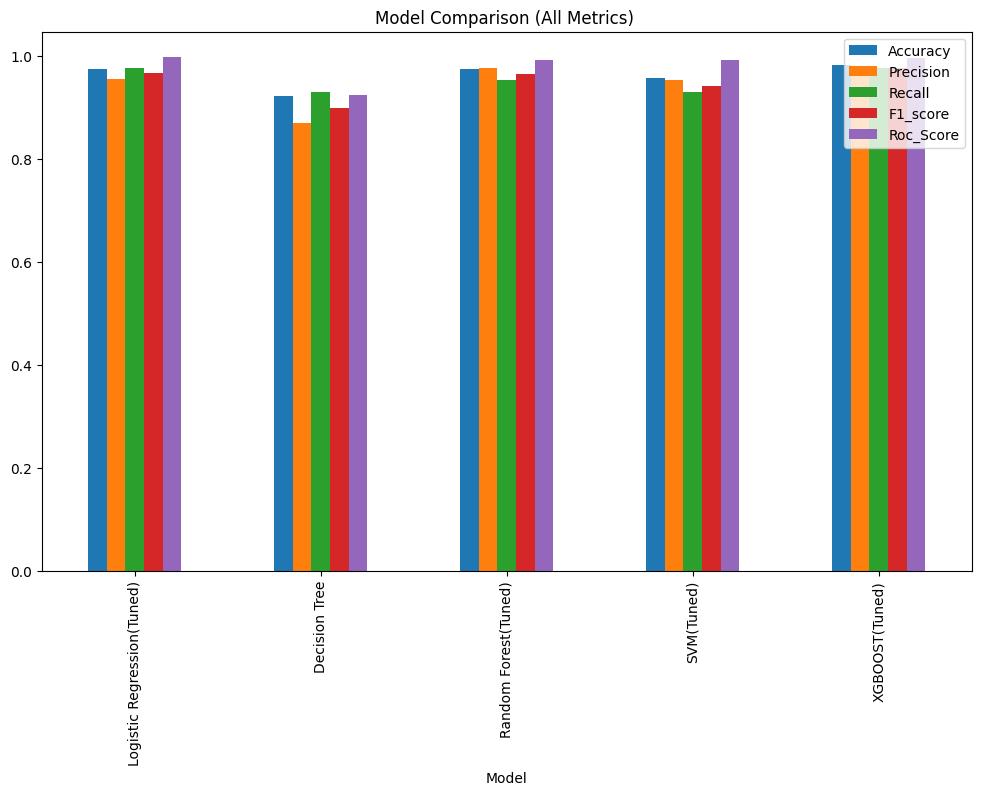

In [106]:
#model comparison after hyperparameter tuning
import pandas as pd
import matplotlib.pyplot as plt
results_updated = pd.DataFrame({
    'Model':['Logistic Regression(Tuned)','Decision Tree','Random Forest(Tuned)','SVM(Tuned)','XGBOOST(Tuned)'],
    'Accuracy' :[lg_tuned_accuracy,dt_accuracy,rf_tuned_accuracy,svm_tuned_accuracy,xgb_tuned_accuracy],
    'Precision' :[lg_tuned_precision,dt_precision,rf_tuned_precision,svm_tuned_precision,xgb_tuned_precision],
    'Recall' :[lg_tuned_recall,dt_recall,rf_tuned_recall,svm_tuned_recall,xgb_tuned_recall],
    'F1_score':[lg_tuned_f1_score,dt_f1,rf_tuned_f1_score,svm_tuned_f1_score,xgb_tuned_f1_score],
    'Roc_Score':[lg_tuned_roc_score,dt_roc,rf_tuned_roc_score,sv_roc,xgb_tuned_roc_score]

})
print(results_updated)

best_model_row = results_updated.loc[results_updated['F1_score'].idxmax()]
print("\nBest Model Based on F1 Score after tuning:", best_model_row['Model'])
print("\n")
results_updated.set_index('Model')[['Accuracy','Precision','Recall','F1_score','Roc_Score']].plot(kind='bar', figsize=(12,7))
plt.title("Model Comparison (All Metrics) ")
plt.show()

                        Model  Accuracy  Precision    Recall  F1_score  \
0  Logistic Regression(Tuned)  0.973684   0.954545  0.976744  0.965517   
1        Decision Tree(Tuned)  0.921053   0.869565  0.930233  0.898876   
2        Random Forest(Tuned)  0.973684   0.976190  0.953488  0.964706   
3                  SVM(Tuned)  0.956140   0.952381  0.930233  0.941176   
4              XGBOOST(Tuned)  0.982456   0.976744  0.976744  0.976744   

   Roc_Score  
0   0.997052  
1   0.922863  
2   0.991811  
3   0.988536  
4   0.995087  

Best Model Based on F1 Score after tuning: XGBOOST(Tuned)




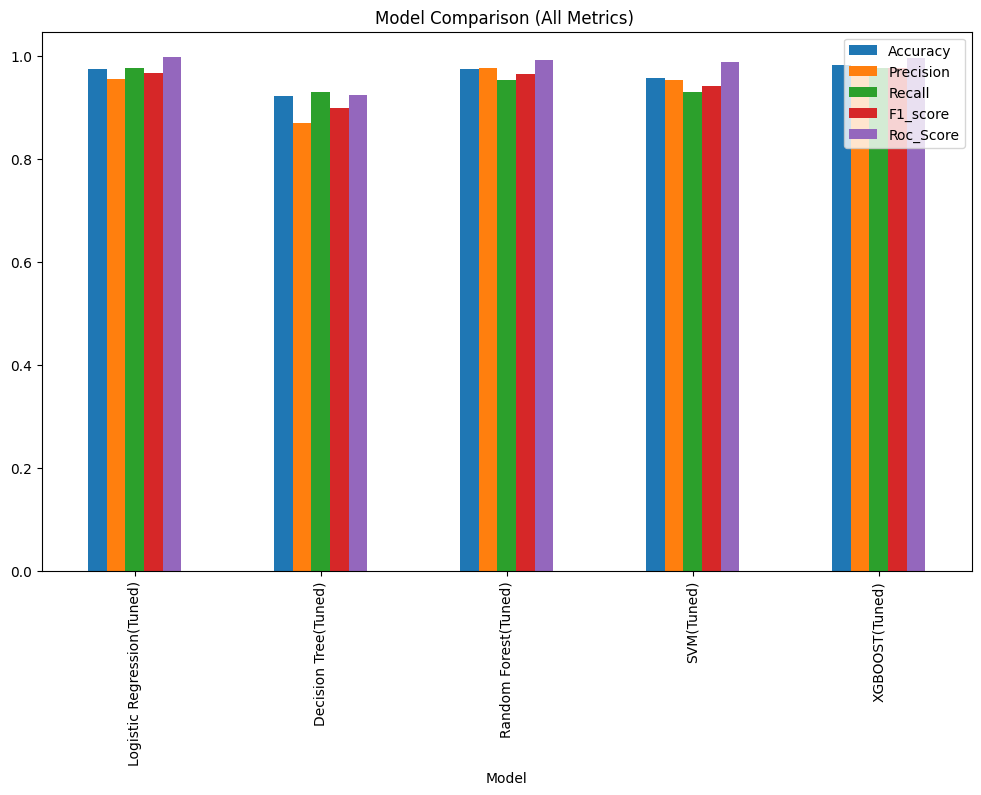

In [107]:
#model comparison after hyperparameter tuning
import pandas as pd
import matplotlib.pyplot as plt
results_updated = pd.DataFrame({
    'Model':['Logistic Regression(Tuned)','Decision Tree(Tuned)','Random Forest(Tuned)','SVM(Tuned)','XGBOOST(Tuned)'],
    'Accuracy' :[lg_tuned_accuracy,dt_accuracy,rf_tuned_accuracy,svm_tuned_accuracy,xgb_tuned_accuracy],
    'Precision' :[lg_tuned_precision,dt_precision,rf_tuned_precision,svm_tuned_precision,xgb_tuned_precision],
    'Recall' :[lg_tuned_recall,dt_recall,rf_tuned_recall,svm_tuned_recall,xgb_tuned_recall],
    'F1_score':[lg_tuned_f1_score,dt_f1,rf_tuned_f1_score,svm_tuned_f1_score,xgb_tuned_f1_score],
    'Roc_Score':[lg_tuned_roc_score,dt_roc,rf_tuned_roc_score,svm_tuned_roc_score,xgb_tuned_roc_score]

})
print(results_updated)

best_model_row = results_updated.loc[results_updated['F1_score'].idxmax()]
print("\nBest Model Based on F1 Score after tuning:", best_model_row['Model'])
print("\n")
results_updated.set_index('Model')[['Accuracy','Precision','Recall','F1_score','Roc_Score']].plot(kind='bar', figsize=(12,7))
plt.title("Model Comparison (All Metrics) ")
plt.show()

In [108]:
#Best model
best_model= results_updated.loc[results_updated['F1_score'].idxmax()]
print("The best performing model :")
print(best_model)

The best performing model :
Model        XGBOOST(Tuned)
Accuracy           0.982456
Precision          0.976744
Recall             0.976744
F1_score           0.976744
Roc_Score          0.995087
Name: 4, dtype: object


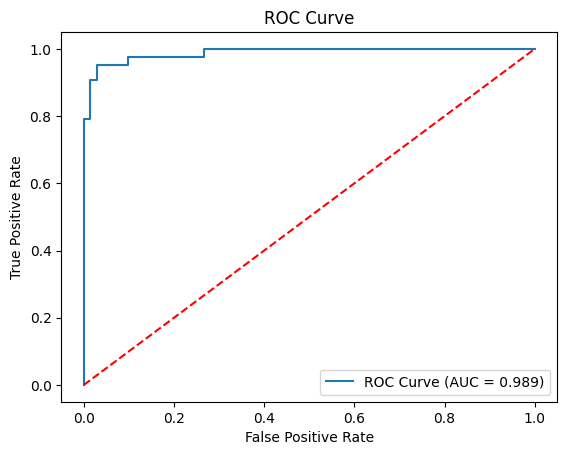

In [109]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm_tuned)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Combined ROC Curve for All Tuned Models

/tmp/ipykernel_1602/922454439.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray', label='Random Classifier')
/tmp/ipykernel_1602/922454439.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray', label='Random Classifier')


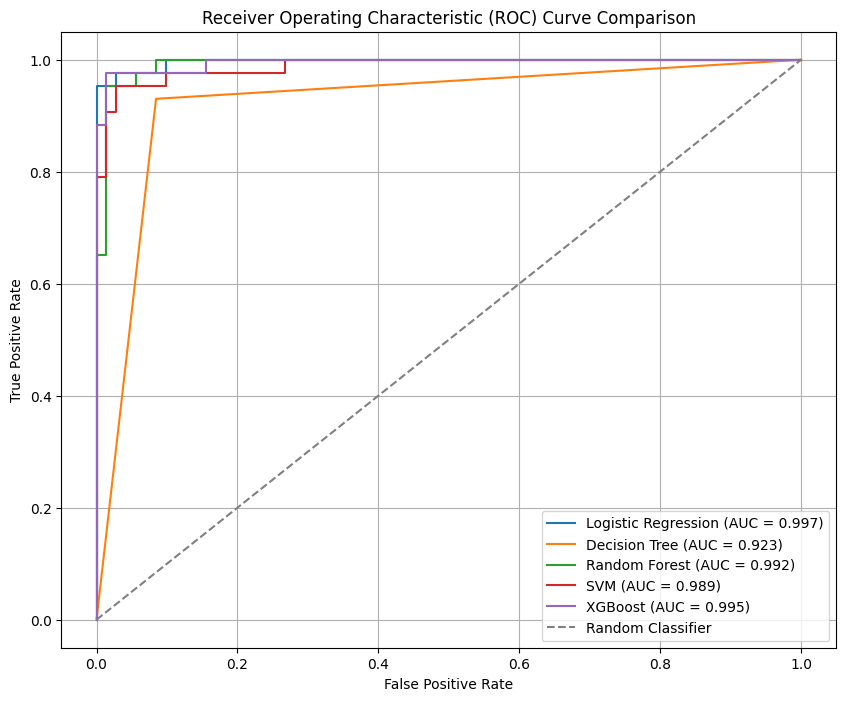

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression (Tuned)
fpr_lg, tpr_lg, _ = roc_curve(y_test, y_prob_lg_tuned)
roc_auc_lg = auc(fpr_lg, tpr_lg)
plt.plot(fpr_lg, tpr_lg, label=f'Logistic Regression (AUC = {roc_auc_lg:.3f})')

# Decision Tree (Tuned)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

# Random Forest (Tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# SVM (Tuned)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm_tuned)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.3f})')

# XGBoost (Tuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_tuned)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/tmp/ipykernel_1602/922454439.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray', label='Random Classifier')
/tmp/ipykernel_1602/922454439.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray', label='Random Classifier')


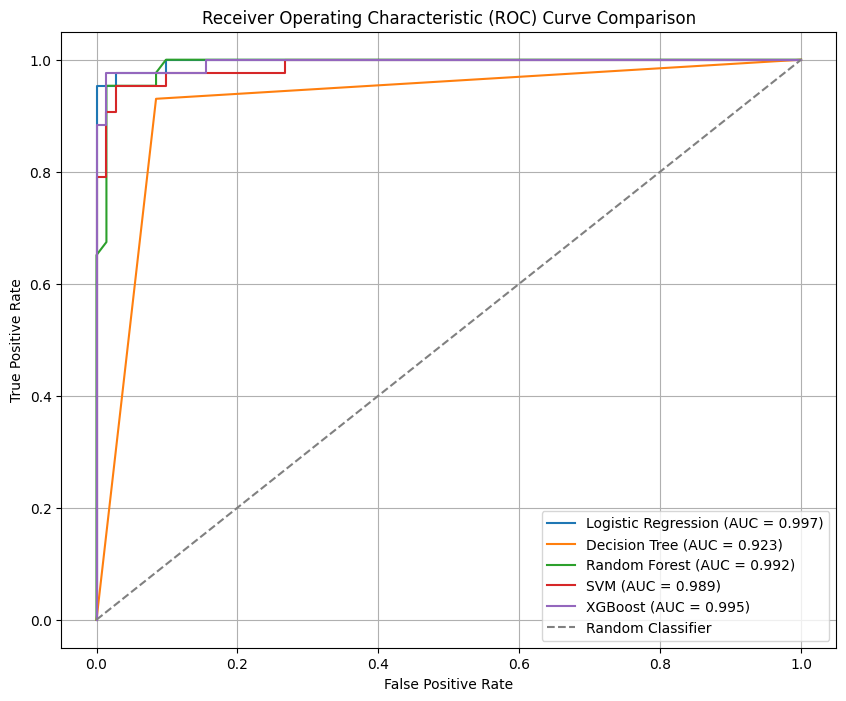

In [111]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression (Tuned)
fpr_lg, tpr_lg, _ = roc_curve(y_test, y_prob_lg_tuned)
roc_auc_lg = auc(fpr_lg, tpr_lg)
plt.plot(fpr_lg, tpr_lg, label=f'Logistic Regression (AUC = {roc_auc_lg:.3f})')

# Decision Tree (Tuned)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

# Random Forest (Tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# SVM (Tuned)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm_tuned)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.3f})')

# XGBoost (Tuned)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_tuned)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [119]:
#feature importance
importance = lg_tuned.coef_[0]

for i,v in enumerate(importance):
    print(x.columns[i],":",v)


radius_mean : 1.2964582947891534
texture_mean : 0.8309924977183106
smoothness_mean : 0.14655893539832354
compactness_mean : 0.1967355739994772
concavity_mean : 0.7854034811269858
symmetry_mean : 0.0723690855898661
fractal_dimension_mean : -0.575395367157117
radius_se : 0.9374581623520468
texture_se : -0.036803455190855344
smoothness_se : -0.018589627008719946
compactness_se : -0.29648198688503363
concavity_se : -0.23051633738959665
concave points_se : 0.3129129373631079
symmetry_se : -0.3104302904197156
fractal_dimension_se : -0.34417777038994896
smoothness_worst : 0.5069153449304101
compactness_worst : 0.31153240775248014
concavity_worst : 0.656039126286748
symmetry_worst : 0.5995261753235305
fractal_dimension_worst : 0.09881646441874953


In [120]:
from sklearn.model_selection import cross_val_score
cross_val_score(lg_tuned, x_train_sm, y_train_sm, cv=5)


array([0.97391304, 0.9826087 , 0.93859649, 0.99122807, 0.98245614])

In [121]:
#factors affecting
corr=df.corr(numeric_only=True)["diagnosis"].sort_values(ascending=False)
print("\nTop factors affecting Cancer")
print(corr[1:4])


Top factors affecting Cancer
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
Name: diagnosis, dtype: float64


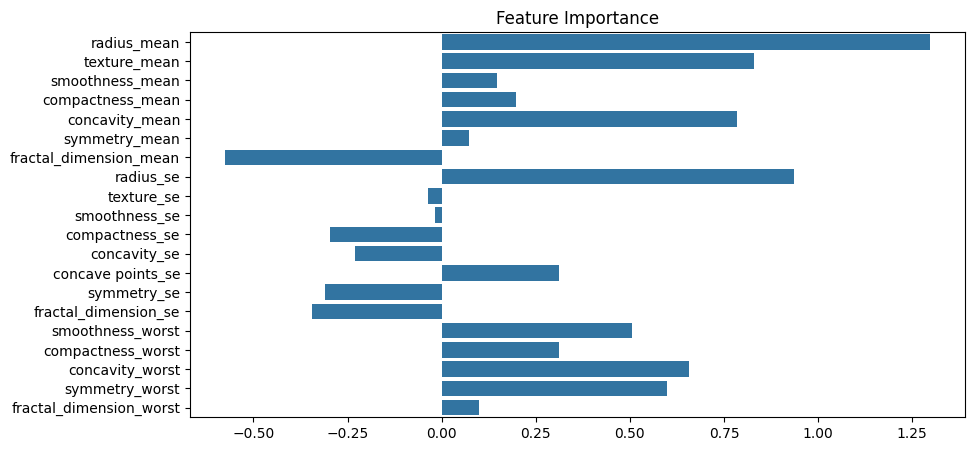

In [117]:
plt.figure(figsize=(10,5))
feature_names = x.columns.tolist()
sns.barplot(x=importance, y=feature_names)
plt.title("Feature Importance")
plt.show()

In [46]:
from google.colab import files
uploaded=files.upload()

Saving Screenshot (656).png to Screenshot (656).png


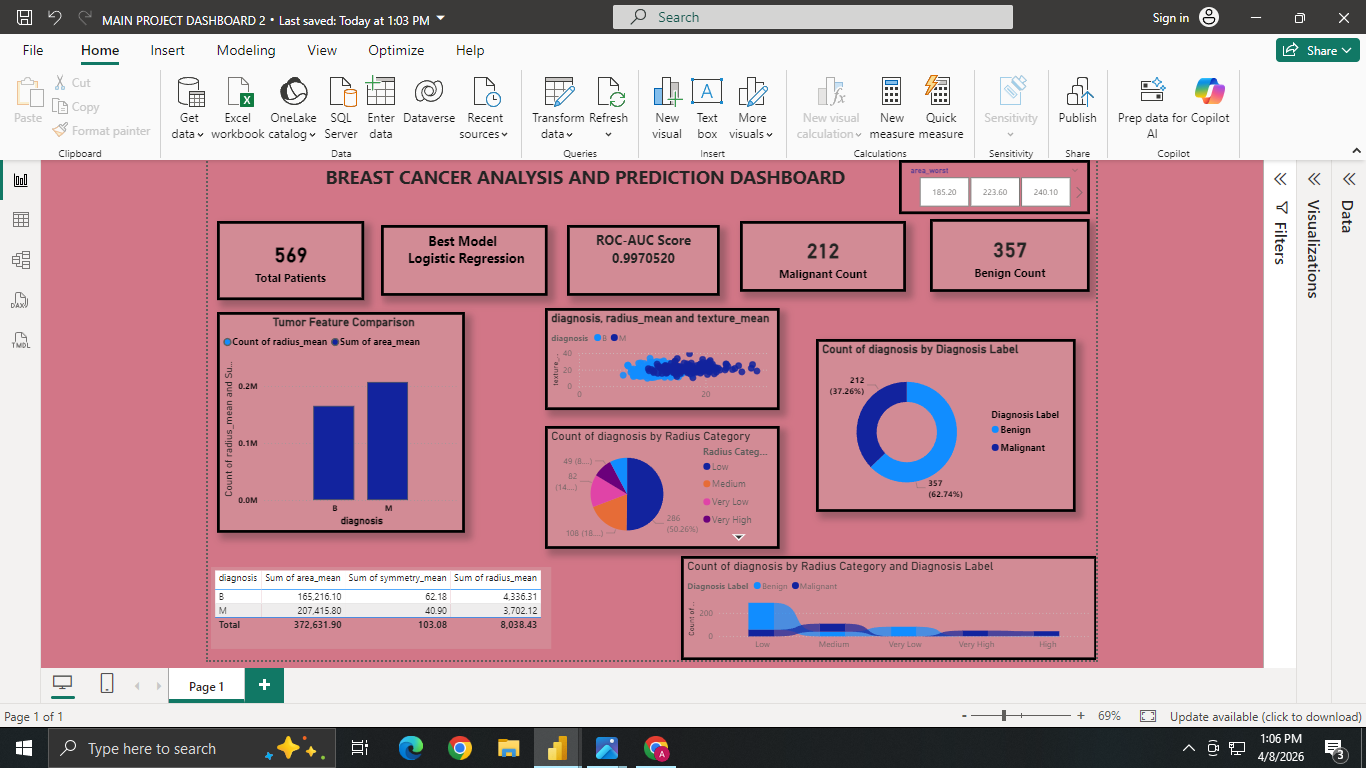

In [47]:
from IPython.display import Image
Image('Screenshot (656).png')